In [1]:
import sys
sys.path.insert(0, "..")

import mne
from pathlib import Path
from src.preprocessing.loader import load_raw
from src.preprocessing.filter import apply_filters
from src.preprocessing.epoching import make_epochs
from src.preprocessing.artifacts import mark_bad_channels, reject_by_amplitude, log_rejection
from src.preprocessing.ica import fit_ica, auto_detect_eog, apply_ica
from pipeline import load_config
# Every module built M1 through M5 so far, all feeding into today's step.

cfg = load_config("../config.yaml")
print("Imports OK")

Imports OK


In [2]:
USE_SAMPLE_DATA = True  # flip to False (and set the path below) to run against a local recording

if USE_SAMPLE_DATA:
    sample_path = mne.datasets.sample.data_path()
    raw_path = sample_path / "MEG" / "sample" / "sample_audvis_raw.fif"
else:
    raw_path = Path(cfg["paths"]["raw_data"]) / "your_recording.fif"

raw = load_raw(str(raw_path))
# eog=True this time (M4 excluded it) -- fit_ica excludes EOG from the
# decomposition via picks="eeg", but auto_detect_eog (tomorrow) needs the
# EOG channel present in `epochs` to correlate against. stim=True keeps
# the trigger channel needed for event-finding below. exclude=[] keeps
# EEG 053 (already flagged bad in the recording's own metadata) around so
# this notebook's own mark_bad_channels call below can demonstrate on it,
# same as M4.
raw_eeg = raw.copy().pick_types(eeg=True, meg=False, stim=True, eog=True, exclude=[])
raw_eeg = mark_bad_channels(raw_eeg, bad_channels=["EEG 053"])

bp = cfg["preprocessing"]["bandpass"]
raw_eeg = apply_filters(raw_eeg, l_freq=bp["l_freq"], h_freq=bp["h_freq"], notch_freq=cfg["preprocessing"]["notch_freq"])

pp = cfg["preprocessing"]
epochs = make_epochs(raw_eeg, tmin=pp["epoch_tmin"], tmax=pp["epoch_tmax"])
epochs_clean = reject_by_amplitude(epochs, peak_to_peak_thresh={"eeg": 150e-6})
# reject_by_amplitude's threshold dict only checks the "eeg" key, so EOG
# passes through untouched.
log_rejection(epochs, epochs_clean)

print(f"Channel types present: {set(epochs_clean.get_channel_types())}")
print(f"Epochs ready for ICA: {len(epochs_clean)}")

Opening raw data file C:\Users\ke725\mne_data\MNE-sample-data\MEG\sample\sample_audvis_raw.fif...


    Read a total of 3 projection items:


        PCA-v1 (1 x 102)  idle


        PCA-v2 (1 x 102)  idle


        PCA-v3 (1 x 102)  idle


...

    Rejecting  epoch based on EEG : ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 007']


    Rejecting  epoch based on EEG : ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 007']


    Rejecting  epoch based on EEG : ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 007']


31 bad epochs dropped


Epochs before rejection : 320
Epochs after rejection  : 289
Dropped                 : 31 (9.7%)
Kept                    : 289 (90.3%)
Channel types present: {'stim', 'eeg', 'eog'}
Epochs ready for ICA: 289


In [3]:
ica = fit_ica(epochs_clean, n_components=20, random_state=42)

print(f"ICA fitted with {ica.n_components_} components")

Fitting ICA to data using 59 channels (please be patient, this may take a while)


C:\Users\ke725\Documents\eeg-project\notebooks\..\src\preprocessing\ica.py:18: RuntimeWarning: The epochs you passed to ICA.fit() were baseline-corrected. However, we suggest to fit ICA only on data that has been high-pass filtered, but NOT baseline-corrected.
  ica.fit(epochs, picks="eeg")


Selecting by number: 20 components


Fitting ICA took 15.2s.


ICA fitted with 20 components


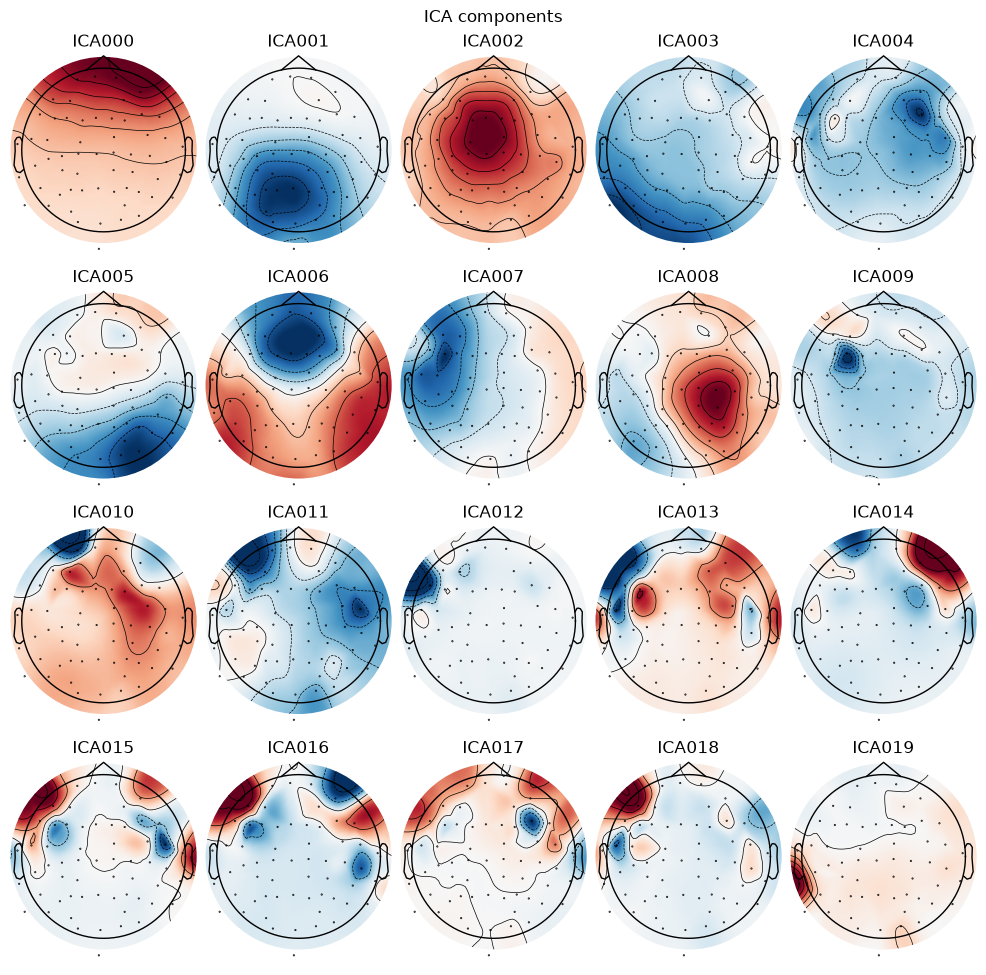

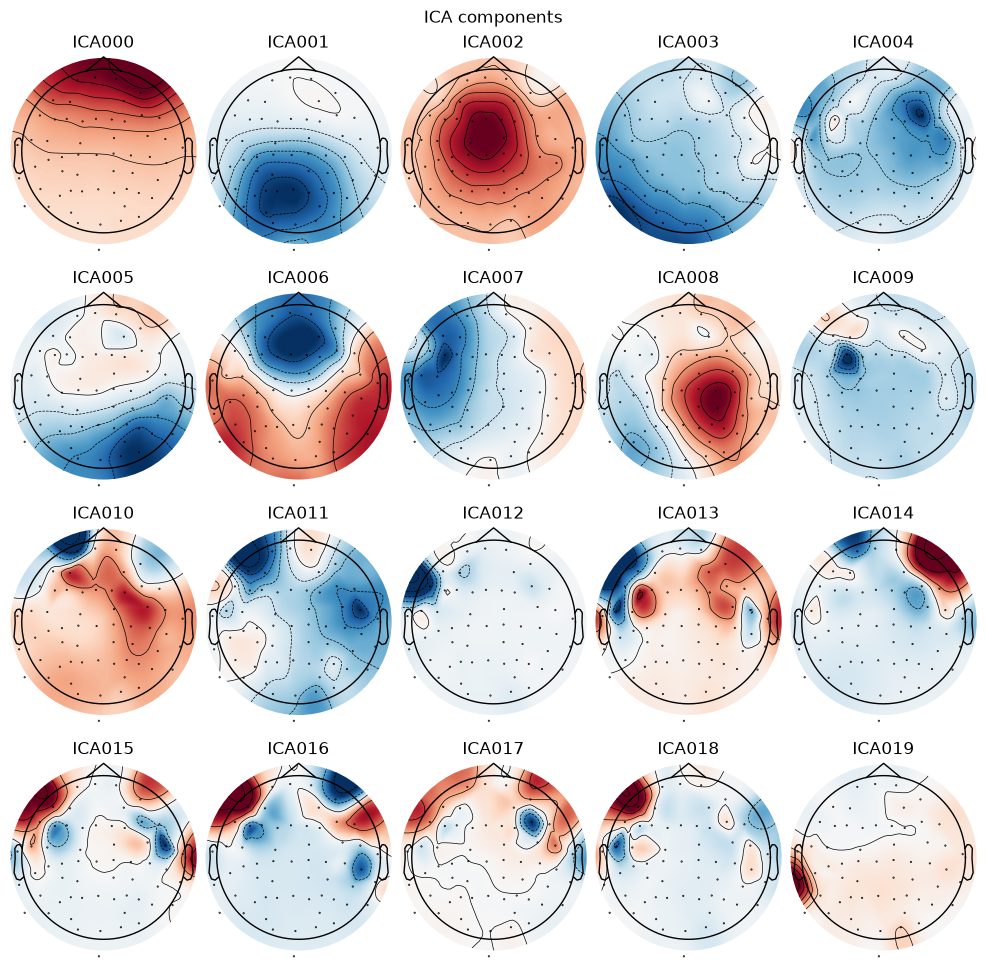

In [4]:
# Compare against M5_concepts.md section 4 (frontal-bilateral = eye,
# edge-concentrated = muscle, diffuse diagonal = cardiac, smooth/central = brain).
ica.plot_components(inst=epochs_clean)

## My Manual Read of the Components

Looking at the topographies in Cell 4, **ICA002** is my primary guess for the eye-blink
component: it's an extremely strong, tightly concentrated, symmetric blob sitting right at
the very front-center of the scalp (roughly over Fpz) — a near-textbook match for the
frontal-bilateral pattern M5_concepts.md §4 describes for blinks, and visually the strongest,
most sharply localized component in the whole set.

**ICA000** is a secondary candidate worth noting honestly rather than ignoring: it's also
frontally-weighted (reddish across the whole front half), but the gradient is broad and
diffuse rather than sharply concentrated, which reads more like a drift/reference artifact
or a diluted mix of frontal sources than a clean single-source blink.

Nothing else in the grid stands out as edge-concentrated (muscle) or diffuse-diagonal
(cardiac) to me — most of the remaining components (ICA010, ICA013, ICA014-018) look
lateralized toward one hemisphere or the temporal edges, which doesn't match either of
those patterns as described in the concepts file either. I'm keeping this guess independent
of any automated result — `auto_detect_eog` hasn't been run yet in this notebook; that
comparison is tomorrow's task (`M5_july12.md` PART 3).

In [5]:
# plot_sources shows each component's activity over time, scrollable, the
# same way raw.plot() scrolls through channels -- except now each "channel"
# is a component's time course, not a physical electrode.
ica.plot_sources(epochs_clean)

Not setting metadata


289 matching events found


No baseline correction applied


0 projection items activated


Using qt as 2D backend.
